# Phase 3: 验证数据集合理性的前置操作（已经弃用）

## 概述 Overview

本Notebook是实验用的副本，基于Phase3_模型验证ipynb文件进行的
* 主要验证数据划分的合理性：随机种子为90的时候，数据划分处在一个合理状态，交叉验证和独立验证不会产生较大区别
* 测试整体的读取流程。


**超参数配置：**
- Logistic Regression: L2正则化, balanced权重
- Random Forest: 100棵树, balanced权重
- XGBoost: GPU加速, max_depth=6, balanced权重

**数据配置：**
- 半衰期阈值：SIF：270，SGF：250
- 半衰期异常值：700

**输入**: 
- `data/mixture/csv/*.csv` - 带分钟标签的CSV  
- `data/mixture/features/*.npz` - RDKit特征矩阵  

**输出**: 
- `data/mixture/outputs/model_results/cv_results/` - CV结果JSON  
- `data/mixture/outputs/model_results/feature_importance/` - 特征重要性CSV  
- `data/mixture/outputs/model_results/transfer_results/` - 迁移学习JSON  
- `data/mixture/figures/phase3/` - 可视化图表  

---

## 1. 环境检查与导入 Environment Setup

In [26]:
# 环境检查
import sys
from pathlib import Path

# 添加项目根目录到路径
project_root = Path.cwd().parent
print(project_root)
sys.path.insert(0, str(project_root / "src"))

# 核心库导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import json
warnings.filterwarnings('ignore')

# 机器学习
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

# 检查GPU可用性
try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        print(f"✓ GPU可用: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠ GPU不可用，将使用CPU训练")
except ImportError:
    gpu_available = False
    print("⚠ PyTorch未安装，将使用CPU训练")

# 设置显示选项
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ 所有库已成功导入")
print(f"✓ 项目根目录: {project_root}")

d:\RA\feature_extraction
⚠ PyTorch未安装，将使用CPU训练
✓ 所有库已成功导入
✓ 项目根目录: d:\RA\feature_extraction


In [27]:

def convert_numpy_types(obj):
    """递归转换numpy类型为Python原生类型"""
    import numpy as np
    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(v) for v in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj


## 2. 参数配置区 Configuration

**⚙️ 根据您的需求修改以下参数**

In [28]:
# ============== 参数配置区 ==============

CONFIG = {
    # 输入输出路径
    'processed_dir': project_root / 'data' / 'mixture' / 'csv',
    'features_dir': project_root / 'data' / 'mixture' / 'features',
    'cv_results_dir': project_root / 'data' / 'mixture'/ 'outputs' / 'phase3' / 'cv_results',
    'feature_importance_dir': project_root / 'data' / 'mixture' / 'outputs' / 'phase3' / 'feature_importance',
    'transfer_results_dir': project_root / 'data' / 'mixture' / 'outputs' / 'phase3' / 'transfer_results',
    'figures_dir': project_root / 'data' / 'mixture'  / 'figures' / 'phase3',
    'independent_results_dir': project_root / 'data' / 'mixture' / 'outputs' / 'phase3' / 'independent_results',
    # 一个临时输出的文件夹
    'temp':project_root/'data'/'mixture'/'outputs'/'temp',

    # 模型选择（可选: 'lr', 'rf', 'xgb'）
    'models_to_train': ['lr', 'rf', 'xgb'],
    
    # 交叉验证参数
    'n_folds': 5,
    'random_state': 42,
    
    # XGBoost参数
    'use_gpu': gpu_available,
    'xgb_max_depth': 6,
    'xgb_learning_rate': 0.1,
    'xgb_n_estimators': 100,
    
    # Random Forest参数
    'rf_n_estimators': 100,
    'rf_n_jobs': -1,
    
    # Logistic Regression参数
    'lr_max_iter': 1000,
    
    # 可视化参数
    'dpi': 300,
    'format': 'png',
    'display_plots': True,
    'max_display_plots': 8,

    # 阈值
    'threshold':{
        'SIF':270,
        'SGF':250
    },

    # 是否只提取单体分子
    'is_monomer': True,
}

# 创建输出目录
for key in ['cv_results_dir', 'feature_importance_dir', 'transfer_results_dir', 'figures_dir', 'independent_results_dir','temp']:
    CONFIG[key].mkdir(parents=True, exist_ok=True)

print("配置参数:")
print(f"  模型: {CONFIG['models_to_train']}")
print(f"  交叉验证折数: {CONFIG['n_folds']}")
print(f"  GPU加速: {CONFIG['use_gpu']}")
print(f"  XGBoost参数: max_depth={CONFIG['xgb_max_depth']}, lr={CONFIG['xgb_learning_rate']}")

配置参数:
  模型: ['lr', 'rf', 'xgb']
  交叉验证折数: 5
  GPU加速: False
  XGBoost参数: max_depth=6, lr=0.1


## 3. 数据加载与二值化 Data Loading & Binarization

In [29]:
def load_and_binarize_dataset(npz_path: Path, csv_path: Path, target: str, is_monomer: bool = None):
    """
    加载数据并将标签二值化，同时可选择只保留monomer或非monomer样本
    (2025-12-15新增功能)
    
    Args:
        npz_path: NPZ特征文件
        csv_path: 处理后的CSV文件（包含分钟标签）
        target: 'SIF' or 'SGF'
        is_monomer: 如果为True，只保留monomer；False，只保留非monomer；None不筛选
    
    Returns:
        X, y_binary, median_threshold, feature_names
    """
    # 加载NPZ特征
    data = np.load(npz_path, allow_pickle=True)
    X = data['X']
    feature_names = data['feature_names']
    ids_npz = data['ids']
    
    # 加载CSV获取分钟标签
    df = pd.read_csv(csv_path)
    df['id'] = df['id'].astype(str)
    
    # ID匹配：这里是建立一个映射数值
    id_to_idx = {str(id_): idx for idx, id_ in enumerate(ids_npz)}
    valid_indices = [] # 确定当前任务用哪一行
    valid_labels = []
    
    label_col = f"{target}_minutes" # 根据任务目标获取分钟数目
    for _, row in df.iterrows():
        row_id = str(row['id'])
        if row_id in id_to_idx:
            #===================================过滤无效标签=========================================
            label= row[label_col]
            if label == -1 or pd.isna(label):# 判断标签有效（对应的任务就只能做对应的二值化）
                continue
            if is_monomer is not None and row['is_monomer'] != is_monomer:  # 判断是否满足monomer条件
                continue
            if row[f"{target}_minutes"]>700: #特殊情况处理，如果是SIF_minuters>700
                continue   
            #=======================================================================================
            # 符合条件则加入
            valid_indices.append(id_to_idx[row_id]) # 获取对应数据的索引/序号
            valid_labels.append(label)              # 获取label
    
    # 筛选有效样本
    X_valid = X[valid_indices]   # 根据序号直接获取到值，这里是numpy的基本用法之一，比如传入【3，7】那么得到的就是第三行和第七行的数值
    y_minutes = np.array(valid_labels)  # 获取y值

    
    
    # 设定阈值========================
    median =None
    if target=='SIF':
        median = CONFIG['threshold']['SIF']
    elif target=='SGF':
        median = CONFIG['threshold']['SGF']

    # 根据阈值判断是否稳定
    y_binary = (y_minutes >= median).astype(int)  # 1=稳定, 0=不稳定
    
    print(f"  样本数: {len(X_valid)}")
    print(f"  中位数阈值（根据数值分析得到的结果）: {median:.1f} 分钟")
    print(f"  稳定/不稳定: {np.sum(y_binary==1)}/{np.sum(y_binary==0)}")
    
    return X_valid, y_binary, median, feature_names


# 加载所有数据集
datasets_data = {}
npz_files = sorted(CONFIG['features_dir'].glob('*.npz'))
# 选择加载数据的时候就指定monomer或非monomer样本
is_monomer = CONFIG['is_monomer'] # 仅加载monomer样本，设置为False则加载非monomer样本，None则不筛选

print(f"加载并二值化 {len(npz_files)} 个数据集:\n")
for npz_file in npz_files:
    dataset_name = npz_file.stem.replace('', '')# 这行代码看起来没啥用，其实是历史遗留问题，不用管也不要动
    csv_file = CONFIG['processed_dir'] / f"{dataset_name}.csv"
    
    print(f"{dataset_name}:")

    # 此处新增数据集加载功能（第四个参数）
    
    # SIF
    X_sif, y_sif, median_sif, feat_names = load_and_binarize_dataset(npz_file, csv_file, 'SIF',is_monomer)
    print(f"  SIF数据选择完成，只获得单体数据")
    
    # SGF
    X_sgf, y_sgf, median_sgf, _ = load_and_binarize_dataset(npz_file, csv_file, 'SGF',is_monomer)
    print(f"  SGF数据选择完成，只获取单体数据\n")
    
    datasets_data[dataset_name] = {
        'X_sif': X_sif,
        'y_sif': y_sif,
        'median_sif': median_sif,
        'X_sgf': X_sgf,
        'y_sgf': y_sgf,
        'median_sgf': median_sgf,
        'feature_names': feat_names,
    }

print(f"✓ 数据加载完成！共 {len(datasets_data)} 个数据集")

#=============对数据进行一些处理=========================
# 字典序
print("查看数据集类型",type(datasets_data))   
# dict_keys(['sif_sgf_second', 'US20140294902A1', 'US9624268', 'US9809623B2', 'WO2017011820A2'])
print("尝试输出数据查看情况",datasets_data.keys()) 


#=============上方为数据的处理区域=======================

加载并二值化 6 个数据集:

mixture_test_:
  样本数: 119
  中位数阈值（根据数值分析得到的结果）: 270.0 分钟
  稳定/不稳定: 32/87
  SIF数据选择完成，只获得单体数据
  样本数: 103
  中位数阈值（根据数值分析得到的结果）: 250.0 分钟
  稳定/不稳定: 22/81
  SGF数据选择完成，只获取单体数据

mixture_test_random77:
  样本数: 123
  中位数阈值（根据数值分析得到的结果）: 270.0 分钟
  稳定/不稳定: 31/92
  SIF数据选择完成，只获得单体数据
  样本数: 107
  中位数阈值（根据数值分析得到的结果）: 250.0 分钟
  稳定/不稳定: 25/82
  SGF数据选择完成，只获取单体数据

mixture_test_random90:
  样本数: 117
  中位数阈值（根据数值分析得到的结果）: 270.0 分钟
  稳定/不稳定: 31/86
  SIF数据选择完成，只获得单体数据
  样本数: 91
  中位数阈值（根据数值分析得到的结果）: 250.0 分钟
  稳定/不稳定: 19/72
  SGF数据选择完成，只获取单体数据

mixture_train_:
  样本数: 395
  中位数阈值（根据数值分析得到的结果）: 270.0 分钟
  稳定/不稳定: 145/250
  SIF数据选择完成，只获得单体数据
  样本数: 300
  中位数阈值（根据数值分析得到的结果）: 250.0 分钟
  稳定/不稳定: 101/199
  SGF数据选择完成，只获取单体数据

mixture_train_random77:
  样本数: 391
  中位数阈值（根据数值分析得到的结果）: 270.0 分钟
  稳定/不稳定: 145/246
  SIF数据选择完成，只获得单体数据
  样本数: 296
  中位数阈值（根据数值分析得到的结果）: 250.0 分钟
  稳定/不稳定: 98/198
  SGF数据选择完成，只获取单体数据

mixture_train_random90:
  样本数: 398
  中位数阈值（根据数值分析得到的结果）: 270.0 分钟
  稳定/不稳定: 146/252
  SIF数据选

## 4. 交叉验证训练 Cross-Validation Training

In [30]:
import random
# 选择模型：这里已经强制了随机种子1-100000
def get_model(model_name: str, use_gpu: bool = False):
    
    CONFIG['random_state']=random.randint(1, 1000000)
    # print("选择模型为", model_name, "随机种子", CONFIG['random_state'])
    """
    创建模型实例
    """
    if model_name == 'lr':
        return LogisticRegression(
            max_iter=CONFIG['lr_max_iter'],
            class_weight='balanced',
            random_state=CONFIG['random_state']
        )
    elif model_name == 'rf':
        return RandomForestClassifier(
            n_estimators=CONFIG['rf_n_estimators'],
            class_weight='balanced',
            n_jobs=CONFIG['rf_n_jobs'],
            random_state=CONFIG['random_state']
        )
    elif model_name == 'xgb':
        params = {
            'max_depth': CONFIG['xgb_max_depth'],
            'learning_rate': CONFIG['xgb_learning_rate'],
            'n_estimators': CONFIG['xgb_n_estimators'],
            'random_state': CONFIG['random_state'],
            'tree_method': 'hist',
        }
        if use_gpu:
            params['device'] = 'cuda:0'
        return XGBClassifier(**params)
    else:
        raise ValueError(f"Unknown model: {model_name}")
# 进行K折交叉验证，
def cross_validate_model(X, y, model_name: str, dataset_name: str, target: str):
    """
    执行k折交叉验证，根据训练数据集自身进行工作
    
    Returns:
        dict: CV结果
    """
    # 自动调整fold数（小数据集）
    min_class_count = np.bincount(y).min()
    n_folds = min(CONFIG['n_folds'], min_class_count)
    if n_folds < CONFIG['n_folds']:
        print(f"    ⚠ 样本数较少，调整fold数为 {n_folds}")
    
    if n_folds < 2:
        print("    ⚠ 样本过少，无法进行分层交叉验证，跳过该任务")
        return None

    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=CONFIG['random_state'])
    
    metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc': []
    }
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 训练模型
        model = get_model(model_name, CONFIG['use_gpu'])
        model.fit(X_train, y_train) # 这个地方是训练模型的核心代码
        
        # 预测
        y_pred = model.predict(X_test)
        # （修改后的probo）
        proba = model.predict_proba(X_test)
        if proba.shape[1] == 2:
            y_proba = proba[:, 1]
        else:
            y_proba = None  # 只有一个类别时，AUC 没有定义
        
        # 计算指标
        metrics['accuracy'].append(accuracy_score(y_test, y_pred))
        metrics['precision'].append(precision_score(y_test, y_pred, average='binary', zero_division=0))
        metrics['recall'].append(recall_score(y_test, y_pred, average='binary', zero_division=0))
        metrics['f1'].append(f1_score(y_test, y_pred, average='binary', zero_division=0))
        
        # AUC（需要至少两个类别，新增一种情况与下面配合，就是只有一种类别）
        if y_proba is not None and len(np.unique(y_test)) > 1:
            metrics['auc'].append(roc_auc_score(y_test, y_proba))
        else:
            metrics['auc'].append(np.nan)
    
    # 汇总结果
    results = {
        'dataset': f'cross_{dataset_name}',
        'target': target,
        'model': model_name,
        'n_folds': n_folds,
        'metrics': metrics,
        'mean_metrics': {k: np.nanmean(v) for k, v in metrics.items()},
        'std_metrics': {k: np.nanstd(v) for k, v in metrics.items()},
    }
    
    return results

def independent_validate(X_train, y_train, X_test, y_test, model_name: str, 
                         dataset_train_name: str, 
                         dataset_test_name: str,
                         target: str):
    """
    在训练集上进行全量训练，在独立的测试集上进行单次验证
    
    Returns:
        dict: 评估结果（结构与原CV结果一致，方便兼容）
    """
    # 检查类别情况，防止只有单类别无法计算指标
    unique_classes = np.unique(y_test)
    if len(unique_classes) < 2:
        print(f"    ⚠ 测试集只有类别 {unique_classes}，无法进行二分类评估，跳过该任务")
        return None

    # --- 核心训练过程 ---
    # 1. 创建模型
    model = get_model(model_name, CONFIG['use_gpu'])
    
    # 2. 直接在全量 X_train 上训练，不再有 Fold 迭代
    model.fit(X_train, y_train) 
    
    # --- 预测过程 ---
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    
    if proba.shape[1] == 2:
        y_proba = proba[:, 1]
    else:
        y_proba = None

    # --- 计算指标 ---
    # 为了保持输出结构一致，我们将结果存入列表（虽然只有一个值）
    metrics = {
        'accuracy': [accuracy_score(y_test, y_pred)],
        'precision': [precision_score(y_test, y_pred, average='binary', zero_division=0)],
        'recall': [recall_score(y_test, y_pred, average='binary', zero_division=0)],
        'f1': [f1_score(y_test, y_pred, average='binary', zero_division=0)],
        'auc': []
    }
    
    if y_proba is not None and len(unique_classes) > 1:
        metrics['auc'].append(roc_auc_score(y_test, y_proba))
    else:
        metrics['auc'].append(np.nan)

    # --- 汇总结果（保持与原 CV 格式兼容） ---
    results = {
        'dataset': f'{dataset_train_name}_{dataset_test_name}',
        'target': target,
        'model': model_name,
        'fold': 1, #  K-Fold
        'metrics': metrics,
        'mean_metrics': {k: np.nanmean(v) for k, v in metrics.items()}, # 均值即本身
        'std_metrics': {k: 0.0 for k in metrics.keys()},                # 单次验证无标准差
    }
    
    return results


# 执行：批量交叉验证
print("开始交叉验证训练...\n")
cv_results_all = []

print(datasets_data.keys())
for dataset_name, data in tqdm(datasets_data.items(), desc="数据集"):
    if dataset_name.startswith('mixture_train_.csv'):
        print("检查交叉验证情况")
        print(f"\n{dataset_name}:")
        for target in ['SIF', 'SGF']:
            X = data[f'X_{target.lower()}']
            y = data[f'y_{target.lower()}']
            
            if len(y) == 0:
                print(f"  {target}: 无有效样本，跳过")
                continue
            
            print(f"  {target}:")
            for model_name in CONFIG['models_to_train']:
                print(f"    {model_name.upper()}...", end=" ")

                #=====增加错误排除逻辑===========================
                try:
                    results = cross_validate_model(X, y, model_name, dataset_name, target)
                except ValueError as e:
                    print(f"只有一种类别，跳过该任务")
                    continue
                # 增加跳出逻辑====================================
                if results is None:
                    print("跳过 ✓")
                    continue
                #===============================================
                cv_results_all.append(results)
                
                # 保存结果
                result_path = CONFIG['cv_results_dir'] / f"{dataset_name}_{target}_{model_name}_cv.json"
                with open(result_path, 'w') as f:
                    json.dump(convert_numpy_types(results), f, indent=2)
                
                print(f"F1={results['mean_metrics']['f1']:.4f} ✓")
    else:
        print(f"\n{dataset_name} 非训练集，稍后进行独立验证")

#====进行独立验证=========================，根据特定的数据集进行验证
print("\n开始独立验证...\n")
independent_results_all = []
# 这里指定训练集和测试集名称
train_dataset_name = 'mixture_train_'
test_dataset_name = 'mixture_test_'
# 获取数据
train_data = datasets_data.get(train_dataset_name)
test_data = datasets_data.get(test_dataset_name)
# 简单判断后进行训练
if train_data is not None and test_data is not None:
    for target in ['SIF', 'SGF']:
        X_train = train_data[f'X_{target.lower()}']
        y_train = train_data[f'y_{target.lower()}']
        X_test = test_data[f'X_{target.lower()}']
        y_test = test_data[f'y_{target.lower()}']
        
        if len(y_train) == 0 or len(y_test) == 0:
            print(f"  {target}: 训练集或测试集无有效样本，跳过")
            continue
        
        print(f"\n独立验证 {train_dataset_name} -> {test_dataset_name}:")
        for model_name in CONFIG['models_to_train']:
            print(f"    {model_name.upper()}...", end=" ")

            try:
                results = independent_validate(
                    X_train, y_train, X_test, y_test,
                    model_name,
                    train_dataset_name,
                    test_dataset_name,
                    target
                )
            except ValueError as e:
                print(f"只有一种类别，跳过该任务")
                continue
            
            if results is None:
                print("跳过 ✓")
                continue

            independent_results_all.append(results)

            # 保存结果
            result_path = CONFIG['independent_results_dir'] / f"{train_dataset_name}_{test_dataset_name}_{target}_{model_name}_independent.json"
            with open(result_path, 'w') as f:
                json.dump(convert_numpy_types(results), f, indent=2)
            
            print(f"F1={results['mean_metrics']['f1']:.4f} ✓")

print(f"\n✓ 交叉验证完成！共 {len(cv_results_all)} 个实验")
print(f"✓ 独立验证完成！共 {len(independent_results_all)} 个实验")
print(f"  结果已保存到: {CONFIG['cv_results_dir'].relative_to(project_root)}")

开始交叉验证训练...

dict_keys(['mixture_test_', 'mixture_test_random77', 'mixture_test_random90', 'mixture_train_', 'mixture_train_random77', 'mixture_train_random90'])


数据集:   0%|          | 0/6 [00:00<?, ?it/s]


mixture_test_ 非训练集，稍后进行独立验证

mixture_test_random77 非训练集，稍后进行独立验证

mixture_test_random90 非训练集，稍后进行独立验证

mixture_train_ 非训练集，稍后进行独立验证

mixture_train_random77 非训练集，稍后进行独立验证

mixture_train_random90 非训练集，稍后进行独立验证

开始独立验证...


独立验证 mixture_train_ -> mixture_test_:
    LR... F1=0.7013 ✓
    RF... F1=0.7606 ✓
    XGB... F1=0.7887 ✓

独立验证 mixture_train_ -> mixture_test_:
    LR... F1=0.7059 ✓
    RF... F1=0.8333 ✓
    XGB... F1=0.7451 ✓

✓ 交叉验证完成！共 0 个实验
✓ 独立验证完成！共 6 个实验
  结果已保存到: data\mixture\outputs\phase3\cv_results


# 4.1，执行交叉验证的代码

50次交叉验证，修改随机种子，检查均值对比，以及稳定性变化



In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 配置
N_RUNS = 30
METRIC_KEYS = ['accuracy', 'precision', 'recall', 'f1', 'auc']
MODELS = CONFIG['models_to_train']
TARGETS = ['SIF', 'SGF']

# 初始化容器：用于存储每一轮的均值结果
# 结构：storage[验证类型][target_model][metric_name] = [value1, value2, ...]
storage = {
    'cv': {f"{t}_{m}": {k: [] for k in METRIC_KEYS} for t in TARGETS for m in MODELS},
    'ind': {f"{t}_{m}": {k: [] for k in METRIC_KEYS} for t in TARGETS for m in MODELS}
}

print(f"🚀 开始大规模验证（共 {N_RUNS} 轮迭代）...")

for run in range(1, N_RUNS + 1):
    # 核心：动态修改随机种子，确保每一轮的划分和模型初始化都不同
    # current_seed = CONFIG['random_state'] + run ，随机种子的逻辑修改执行都会改变，我就不信了
    
    # --- 交叉验证部分 ---
    for dataset_name, data in datasets_data.items():
        if dataset_name.startswith('mixture_train_random'):
            for target in TARGETS:
                X, y = data[f'X_{target.lower()}'], data[f'y_{target.lower()}']
                if len(y) == 0: continue
                
                for model_name in MODELS:
                    # 更新配置中的种子（假设你的模型创建函数引用了CONFIG）
                    # CONFIG['random_state'] +=1
                    # print(f"当前的运行为{run}次的独立验证，任务{target}，模型{model_name}随机种子为",CONFIG['random_state'])
                    try:
                        res = cross_validate_model(X, y, model_name, dataset_name, target)
                        if res:
                            for k in METRIC_KEYS:
                                storage['cv'][f"{target}_{model_name}"][k].append(res['mean_metrics'][k])
                    except: continue

    # --- 独立验证部分 ---
    train_data = datasets_data.get('mixture_train_random77')
    test_data = datasets_data.get('mixture_test_random77')
    if train_data and test_data:
        for target in TARGETS:
            X_tr, y_tr = train_data[f'X_{target.lower()}'], train_data[f'y_{target.lower()}']
            X_te, y_te = test_data[f'X_{target.lower()}'], test_data[f'y_{target.lower()}']
            
            for model_name in MODELS:
                # CONFIG['random_state'] +=1
                # print(f"当前的运行为{run}次的独立验证，任务{target}，模型{model_name}随机种子为",CONFIG['random_state'])
                try:
                    # 注意：如果independent_validate内部涉及随机划分，种子也会生效
                    res = independent_validate(X_tr, y_tr, X_te, y_te, model_name, "mixture_train_random77", "mixture_train_random77", target)
                    if res:
                        for k in METRIC_KEYS:
                            storage['ind'][f"{target}_{model_name}"][k].append(res['mean_metrics'][k])
                
                except Exception as e: 
                    print(f"  ⚠ 独立验证出错: {e}")
                    continue
    
    if run % 10 == 0:
        print(f"已完成 {run}/{N_RUNS} 轮迭代...")

# 汇总输出汇总
print("\n" + "="*30 + " 最终结果汇总 " + "="*30)
for mode in ['cv', 'ind']:
    print(f"\n[{mode.upper()} 模式最终平均值]:")
    for key, metrics in storage[mode].items():
        print(f"  {key}:")
        for m_name, values in metrics.items():
            if values:
                print(f"    {m_name}: {np.nanmean(values):.4f}")


🚀 开始大规模验证（共 30 轮迭代）...
已完成 10/30 轮迭代...
已完成 20/30 轮迭代...
已完成 30/30 轮迭代...

============================== 最终结果汇总 ==============================

[CV 模式最终平均值]:
  SIF_lr:
    accuracy: 0.7070
    precision: 0.5856
    recall: 0.7188
    f1: 0.6431
    auc: 0.7962
  SIF_rf:
    accuracy: 0.7099
    precision: 0.6082
    recall: 0.6190
    f1: 0.6101
    auc: 0.7979
  SIF_xgb:
    accuracy: 0.6966
    precision: 0.5948
    recall: 0.5775
    f1: 0.5819
    auc: 0.7919
  SGF_lr:
    accuracy: 0.7714
    precision: 0.6424
    recall: 0.7277
    f1: 0.6783
    auc: 0.8496
  SGF_rf:
    accuracy: 0.7620
    precision: 0.6498
    recall: 0.6389
    f1: 0.6391
    auc: 0.8485
  SGF_xgb:
    accuracy: 0.7407
    precision: 0.6206
    recall: 0.5913
    f1: 0.6002
    auc: 0.8350

[IND 模式最终平均值]:
  SIF_lr:
    accuracy: 0.8130
    precision: 0.5909
    recall: 0.8387
    f1: 0.6933
    auc: 0.8769
  SIF_rf:
    accuracy: 0.7799
    precision: 0.5528
    recall: 0.6656
    f1: 0.6038
    auc: 0.8740

# 4.2 绘图和执行结果

上述的交叉验证和独立验证结果会运行50次，然后计算各类指标的平均值并且绘图

* **雷达图**：比较交叉验证和独立验证的结果，输出地点为figures/phase3
* **暂未确定**：输出地点为outputs/temp


✅ 最终平均值已存入: d:\RA\feature_extraction\data\mixture\outputs\temp\final_avg_random77_special(4268)_distribution_mixture.json

✅ 整合雷达图已保存至: d:\RA\feature_extraction\data\mixture\outputs\temp\radar_comparison_random77_special(4268)_distribution_mixture.png


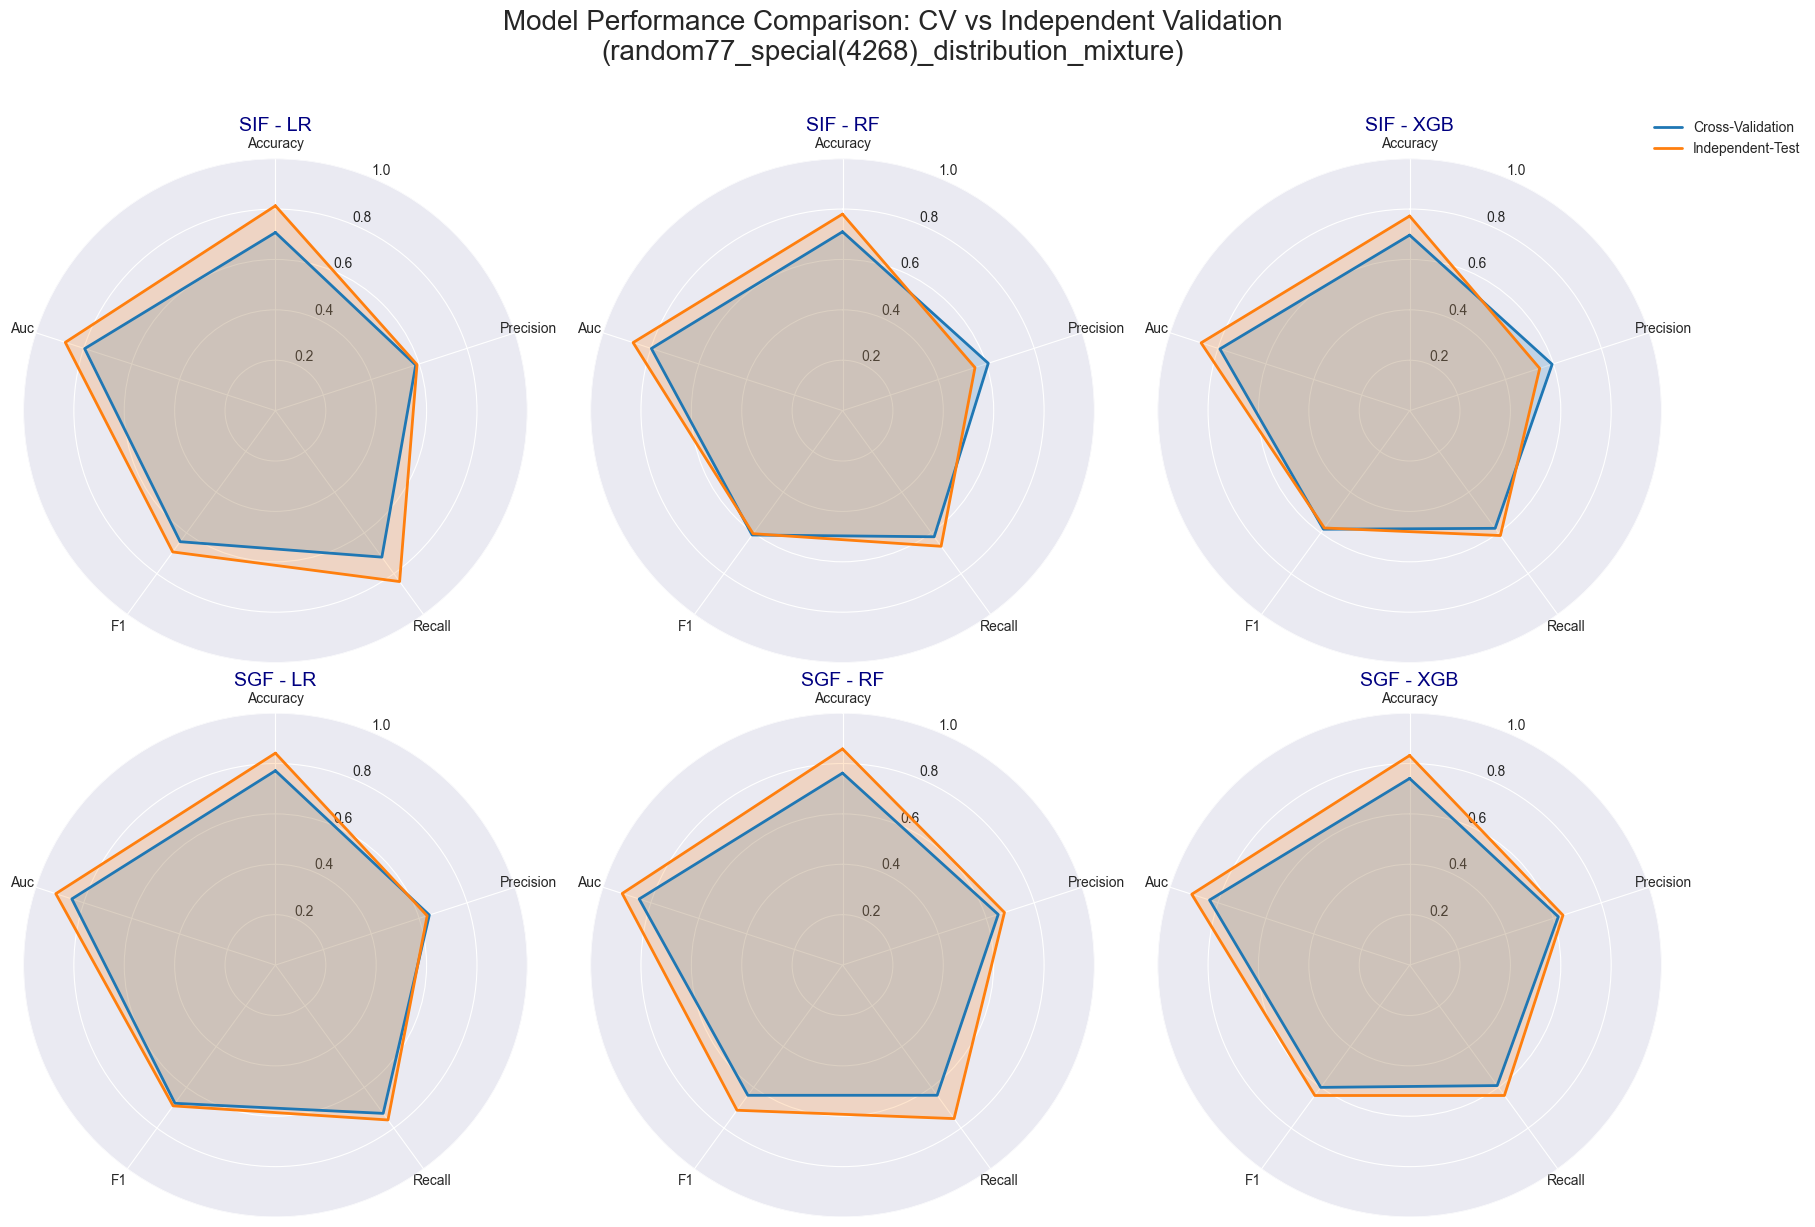

In [32]:
# 绘图（雷达图）
def plot_multi_run_results(storage_data, title):
    fig, axes = plt.subplots(6, 1, figsize=(12, 24), sharex=True)
    plot_keys = list(storage_data.keys()) # ['SIF_lr', 'SIF_rf', ...]
    
    colors = {'accuracy': 'b', 'precision': 'g', 'recall': 'r', 'f1': 'm', 'auc': 'y'}
    
    for i, key in enumerate(plot_keys):
        ax = axes[i]
        for m_name in METRIC_KEYS:
            values = storage_data[key][m_name]
            if not values: continue
            
            x = range(1, len(values) + 1)
            mean_val = np.nanmean(values)
            
            # 绘制实线（单次波动）
            ax.plot(x, values, label=f"{m_name} (avg: {mean_val:.2f})", color=colors[m_name], alpha=0.6)
            # 绘制虚线（平均值水平线）
            ax.axhline(y=mean_val, color=colors[m_name], linestyle='--', alpha=0.8)
            
        ax.set_title(f"{title}: {key.upper()}")
        ax.set_ylabel("Score")
        ax.legend(loc='upper right', fontsize='small', ncol=5)
        ax.grid(True, alpha=0.3)

    plt.xlabel("Run Index (Random Seed Iteration)")
    plt.tight_layout()
    plt.show()

# 调用绘图
# plot_multi_run_results(storage['cv'], "Cross Validation (50 Runs)")
# plot_multi_run_results(storage['ind'], "Independent Validation (50 Runs)")

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_radar_comparison_consolidated(storage, metric_keys, targets, models, message: str = "default_"):
    """
    整合 2x3 的雷达图矩阵，并自动保存到指定路径
    """
    # 1. 基础配置
    labels = [k.capitalize() for k in metric_keys]
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    # 2. 创建 2行3列 的画布 (Row: Targets, Col: Models)
    fig, axes = plt.subplots(len(targets), len(models), figsize=(18, 12), subplot_kw=dict(polar=True))
    fig.suptitle(f"Model Performance Comparison: CV vs Independent Validation\n({message.strip('_')})", 
                 fontsize=20, y=1.02)

    # 3. 循环填充子图
    for t_idx, target in enumerate(targets):
        for m_idx, model in enumerate(models):
            key = f"{target}_{model}"
            ax = axes[t_idx, m_idx]
            
            # 提取数据均值
            cv_vals = [np.nanmean(storage['cv'][key][m]) if storage['cv'][key][m] else 0 for m in metric_keys]
            ind_vals = [np.nanmean(storage['ind'][key][m]) if storage['ind'][key][m] else 0 for m in metric_keys]
            
            cv_vals += cv_vals[:1]
            ind_vals += ind_vals[:1]
            
            # 绘图 - CV (蓝色)
            ax.plot(angles, cv_vals, color='#1f77b4', linewidth=2, label='Cross-Validation')
            ax.fill(angles, cv_vals, color='#1f77b4', alpha=0.2)
            
            # 绘图 - IND (橙色)
            ax.plot(angles, ind_vals, color='#ff7f0e', linewidth=2, label='Independent-Test')
            ax.fill(angles, ind_vals, color='#ff7f0e', alpha=0.2)
            
            # 装饰美化
            ax.set_theta_offset(np.pi / 2)
            ax.set_theta_direction(-1)
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(labels, fontsize=10)
            ax.set_ylim(0, 1.0)
            
            # 设置标题：第一行显示模型名，每行左侧显示任务名
            title = f"{target} - {model.upper()}"
            ax.set_title(title, size=14, color='navy', pad=20)

            # 只在右上角第一个子图显示图例
            if t_idx == 0 and m_idx == 2:
                ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    # 4. 自动保存逻辑 (沿用你的 CONFIG 风格)
    plt.tight_layout()
    
    # 假设你的 CONFIG['results_dir'] 或类似路径已定义
    save_filename = f"radar_comparison_{message}.png"
    save_path = CONFIG['temp'] / save_filename
    
    # 确保文件夹存在
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ 整合雷达图已保存至: {save_path}")
    
    # 是否在运行脚本时直接显示
    # plt.show() 




import json
import datetime
import numpy as np
from pathlib import Path

def save_final_summary_to_temp(storage, message: str = "default"):
    """
    将 CV 和 IND 的最终平均指标汇总到一个 JSON，存入 temp 文件夹
    """
    # 1. 路径设置：在项目根目录或指定目录下创建 temp
    # 优先从 CONFIG 获取基础目录，否则取当前路径
    base_dir = CONFIG.get('base_dir', Path('.'))
    temp_dir = base_dir / "temp"
    temp_dir.mkdir(parents=True, exist_ok=True)
    
    # 2. 汇总平均值并添加元信息
    final_output = {
        "metadata": {
            "message": message,
            "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "n_runs": N_RUNS,
            "description": "Cross-Validation (CV) and Independent-Validation (IND) Average Metrics"
        },
        "results": {
            "cv": {},
            "ind": {}
        }
    }

    # 3. 计算均值并存入
    for mode in ['cv', 'ind']:
        for key, metrics in storage[mode].items():
            final_output["results"][mode][key] = {
                m_name: round(float(np.nanmean(values)), 4) if values else None 
                for m_name, values in metrics.items()
            }

    # 4. 写入文件
    file_path = CONFIG['temp'] / f"final_avg_{message}.json"
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(final_output, f, indent=4, ensure_ascii=False)

    print(f"\n✅ 最终平均值已存入: {file_path}")

# 准备的输出配置（数据集情况，是不是按照全额抽取的情况）

message="random77_special(4268)_distribution_mixture"


# --- 紧跟在你的汇总打印逻辑之后调用 ---
save_final_summary_to_temp(storage, message=message)

# --- 执行绘图与保存 ---
# 传入你的 message 标识
plot_radar_comparison_consolidated(
    storage, 
    METRIC_KEYS, 
    TARGETS, 
    MODELS, 
    message=message
)

## 5. 特征重要性分析 Feature Importance

In [ ]:
# 提取RF和XGBoost的特征重要性（只对一个数据集示例）
print("提取特征重要性...\n")

importance_count = 0
for dataset_name, data in datasets_data.items():
    for target in ['SIF', 'SGF']:
        X = data[f'X_{target.lower()}']
        y = data[f'y_{target.lower()}']
        feature_names = data['feature_names']
        
        if len(y) == 0:
            continue
        
        # RF特征重要性
        rf = get_model('rf', False)
        rf.fit(X, y)
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        imp_path = CONFIG['feature_importance_dir'] / f"{dataset_name}_{target}_rf_importance.csv"
        importance_df.to_csv(imp_path, index=False)
        importance_count += 1
        
        # XGBoost特征重要性
        xgb = get_model('xgb', CONFIG['use_gpu'])

        # 排除特殊情况
        try:
            xgb.fit(X, y)
        except Exception as e:
            print(f"跳过XGBoost特征重要性提取，错误信息: {e}")
            continue
        
        
        importance_df_xgb = pd.DataFrame({
            'feature': feature_names,
            'importance': xgb.feature_importances_
        }).sort_values('importance', ascending=False)
        
        imp_path_xgb = CONFIG['feature_importance_dir'] / f"{dataset_name}_{target}_xgb_importance.csv"
        importance_df_xgb.to_csv(imp_path_xgb, index=False)
        importance_count += 1

print(f"✓ 特征重要性提取完成！共 {importance_count} 个文件")
print(f"  结果已保存到: {CONFIG['feature_importance_dir'].relative_to(project_root)}")

## 6. 迁移学习 Transfer Learning

评估模型在不同数据集间的泛化能力（Train on A, Test on B）

In [ ]:
def transfer_learning_test(X_train, y_train, X_test, y_test, model_name: str, use_gpu: bool = False):
    """
    迁移学习测试
    """
    model = get_model(model_name, use_gpu)

            # 排除特殊情况
    try:
        xgb.fit(X, y)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    except Exception as e:
        print(f"由于标签问题无法成功进行迁移学习测试，跳过该任务")
        return None
        
    
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='binary', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='binary', zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
    }
    
    return metrics

# 执行：双向迁移学习
print("开始迁移学习测试...\n")
transfer_results_all = []
dataset_names = list(datasets_data.keys())

for i, train_dataset in enumerate(dataset_names):
    for j, test_dataset in enumerate(dataset_names):
        if i == j:  # 跳过自己
            continue
        
        print(f"{train_dataset} → {test_dataset}:")
        
        for target in ['SIF', 'SGF']:
            X_train = datasets_data[train_dataset][f'X_{target.lower()}']
            y_train = datasets_data[train_dataset][f'y_{target.lower()}']
            X_test = datasets_data[test_dataset][f'X_{target.lower()}']
            y_test = datasets_data[test_dataset][f'y_{target.lower()}']
            
            if len(y_train) == 0 or len(y_test) == 0:
                print(f"  {target}: 样本不足，跳过")
                continue
            
            print(f"  {target}:", end=" ")
            for model_name in CONFIG['models_to_train']:
                metrics = transfer_learning_test(X_train, y_train, X_test, y_test, model_name, CONFIG['use_gpu'])
                
                result = {
                    'train_dataset': train_dataset,
                    'test_dataset': test_dataset,
                    'target': target,
                    'model': model_name,
                    'metrics': metrics,
                }
                transfer_results_all.append(result)
                
                # 保存结果
                result_path = CONFIG['transfer_results_dir'] / f"{train_dataset}_to_{test_dataset}_{target}_{model_name}.json"
                with open(result_path, 'w') as f:
                    json.dump(result, f, indent=2)
                
                if metrics is None:
                    print(f"{model_name.upper()}(跳过) ", end=" ")
                else:
                    print(f"{model_name.upper()}(F1={metrics['f1']:.3f})", end=" ")
            print()

print(f"\n✓ 迁移学习完成！共 {len(transfer_results_all)} 个实验")
print(f"  结果已保存到: {CONFIG['transfer_results_dir'].relative_to(project_root)}")

## 7. 结果可视化 Visualization

In [ ]:
# 7.2 迁移学习热力图（支持 0 值灰色 + 特定数据集加粗框）
print("\n生成迁移学习热力图...")

highlight_pairs = [
    ('US9624268', 'WO2017011820A2'),
    ('WO2017011820A2', 'US9624268')
]

for target in ['SIF', 'SGF']:
    for model in ['lr', 'rf', 'xgb']:
        # 构建F1 Score矩阵
        transfer_df = pd.DataFrame([{
            'train': r['train_dataset'],
            'test': r['test_dataset'],
            'f1': r['metrics']['f1'] if r['metrics'] is not None else np.nan
        } for r in transfer_results_all
          if r['target'] == target and r['model'] == model])

        if len(transfer_df) == 0:
            continue

        heatmap_data = transfer_df.pivot(
            index='train',
            columns='test',
            values='f1'
        )

        # ========= 关键 mask =========
        nan_mask = heatmap_data.isna()     # NaN → 空白
        zero_mask = heatmap_data == 0      # 0 → 灰色

        fig, ax = plt.subplots(figsize=(10, 8))

        # ========= 第一层：正常 F1 =========
        sns.heatmap(
            heatmap_data,
            mask=nan_mask | zero_mask,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            ax=ax,
            cbar_kws={'label': 'F1 Score'}
        )

        # ========= 第二层：F1 == 0 → 特殊灰色 =========
        sns.heatmap(
            heatmap_data,
            mask=~zero_mask,
            annot=True,
            fmt='.3f',
            cmap=sns.color_palette(['#B0B0B0']),  # 特殊灰
            cbar=False,
            ax=ax
        )

        # ========= 加粗框：指定数据集双向迁移 =========
        for train_ds, test_ds in highlight_pairs:
            if train_ds in heatmap_data.index and test_ds in heatmap_data.columns:
                y = heatmap_data.index.get_loc(train_ds)
                x = heatmap_data.columns.get_loc(test_ds)

                rect = plt.Rectangle(
                    (x, y),
                    1, 1,
                    fill=False,
                    edgecolor='black',
                    linewidth=2.5
                )
                ax.add_patch(rect)

        # ========= 图形设置 =========
        ax.set_title(
            f'{target} - {model.upper()} transfer learning\n'
            f'(row=train set, column=test set)',
            fontsize=13,
            fontweight='bold'
        )
        ax.set_xlabel('test1 set', fontsize=11)
        ax.set_ylabel('train set', fontsize=11)

        plt.tight_layout()

        heatmap_path = (
            CONFIG['figures_dir']
            / f'transfer_heatmap_{target}_{model}.png'
        )
        plt.savefig(
            heatmap_path,
            dpi=CONFIG['dpi'],
            bbox_inches='tight'
        )
        print(f"✓ 已保存: {heatmap_path.name}")

        if CONFIG['display_plots']:
            plt.show()
        else:
            plt.close()


## 8. 结果总结 Summary

In [ ]:
# 我想这里应该是不需要的